# 🧠 Brain Tumor MRI Classification — Combined Pipeline
### Contour Cropping + Baseline CNN vs. EfficientNetV2B0 Transfer Learning + Grad-CAM

This notebook combines the strengths of two separate approaches into one rigorous pipeline:

1. **Clean preprocessing** — OpenCV contour cropping removes the black background/skull margin around the brain, so the model learns anatomy, not noise.
2. **Strict data isolation** — The `Testing/` folder is never touched during training or model selection. It is only used once, at the very end, for final evaluation of both models. This avoids the classic mistake of reporting "validation accuracy" as if it were test accuracy.
3. **Two models, compared fairly** — A custom CNN trained from scratch, and an EfficientNetV2B0 transfer-learning model. Both are evaluated the same way on the same held-out set, so the comparison is meaningful (and is a strong talking point in interviews: *why* does transfer learning help here?).
4. **Explainability** — Grad-CAM heatmaps show *where* the trained model is looking when it makes a prediction, which is the kind of thing most student projects skip entirely.

**Dataset expected:** [Brain Tumor MRI Dataset (masoudnickparvar)](https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset) — 4 classes: `glioma`, `meningioma`, `notumor`, `pituitary`, already split into `Training/` and `Testing/` folders.


## 1. Setup

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications import EfficientNetV2B0
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input as efficientnet_preprocess

# --- Mixed precision: free speedup on modern GPUs (RTX 20/30/40, T4, P100) ---
# Matmuls/convs run in float16, weights are kept in float32 for stability.
# Must be set before any model is built.
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy("mixed_float16")

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Let the GPU allocate memory as needed instead of grabbing it all upfront
gpus = tf.config.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

print(f"TensorFlow version: {tf.__version__}")
print(f"GPUs available: {len(gpus)}")
print(f"Mixed precision policy: {mixed_precision.global_policy()}")


TensorFlow version: 2.20.0
GPUs available: 1
Mixed precision policy: <DTypePolicy "mixed_float16">


## 2. Brain Contour Cropping

MRI scans contain a lot of uninformative black background. Left in, a CNN will happily waste
capacity learning that background rather than the actual pathology. This function:

1. Converts to grayscale and blurs slightly to remove sensor noise.
2. Thresholds to isolate the brightest object (the brain).
3. Finds the extreme contour points and crops tightly to them.


In [2]:
def crop_brain_contour(image):
    """Crop an MRI image down to just the brain, discarding black background."""
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (5, 5), 0)

    thresh = cv2.threshold(gray, 45, 255, cv2.THRESH_BINARY)[1]
    thresh = cv2.erode(thresh, None, iterations=2)
    thresh = cv2.dilate(thresh, None, iterations=2)

    cnts = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cnts = cnts[0] if len(cnts) == 2 else cnts[1]

    if len(cnts) == 0:
        return image  # fall back to original if no contour found

    c = max(cnts, key=cv2.contourArea)

    extLeft = tuple(c[c[:, :, 0].argmin()][0])
    extRight = tuple(c[c[:, :, 0].argmax()][0])
    extTop = tuple(c[c[:, :, 1].argmin()][0])
    extBot = tuple(c[c[:, :, 1].argmax()][0])

    cropped = image[extTop[1]:extBot[1], extLeft[0]:extRight[0]]

    # Guard against a degenerate crop (e.g. near-empty image)
    if cropped.size == 0:
        return image
    return cropped


# Quick sanity check on one image once the dataset path is set below.


## 3. Locate the Dataset & Load Images

This cell auto-detects whether you're on **Kaggle** or **Colab** and handles each correctly:

- **Kaggle:** searches `/kaggle/input` for a folder containing `Training/` and `Testing/` — just
  make sure you've attached the dataset to the notebook (Add Data → search
  `masoudnickparvar/brain-tumor-mri-dataset`).
- **Colab:** downloads the dataset directly from Kaggle using the Kaggle API. You need a
  `kaggle.json` API token (Kaggle → Settings → Create New API Token, downloads the file). The cell
  will prompt you to upload it the first time.

**Important:** `Testing/` is loaded here but is not used again until Section 7 (final evaluation).
It is never used for training, validation, early stopping, or model selection.


In [3]:
def find_dataset(search_root="/kaggle/input"):
    """Find a directory containing both Training/ and Testing/ folders."""
    for root, dirs, files in os.walk(search_root):
        if "Training" in dirs and "Testing" in dirs:
            return root
    return None


def in_colab():
    """Check whether the notebook is running in Google Colab."""
    try:
        import google.colab
        return True
    except ImportError:
        return False


if in_colab():
    print("Running in Google Colab — downloading dataset with KaggleHub...")

    # Install KaggleHub
    !pip install -q kagglehub

    import kagglehub

    # Download/cache the dataset
    BASE_DIR = kagglehub.dataset_download(
        "masoudnickparvar/brain-tumor-mri-dataset"
    )

else:
    print("Running on Kaggle — searching /kaggle/input for the dataset...")

    BASE_DIR = find_dataset("/kaggle/input")

    if BASE_DIR is None:
        raise FileNotFoundError(
            "Dataset not found under /kaggle/input. "
            "Attach 'masoudnickparvar/brain-tumor-mri-dataset' "
            "to the Kaggle notebook."
        )


# --------------------------------------------------
# Dataset paths
# --------------------------------------------------

TRAIN_DIR = os.path.join(BASE_DIR, "Training")
TEST_DIR = os.path.join(BASE_DIR, "Testing")


# Verify that the dataset structure is correct
assert os.path.isdir(TRAIN_DIR), (
    f"Training folder not found: {TRAIN_DIR}"
)

assert os.path.isdir(TEST_DIR), (
    f"Testing folder not found: {TEST_DIR}"
)


# --------------------------------------------------
# Dataset configuration
# --------------------------------------------------

LABELS = [
    "glioma",
    "meningioma",
    "notumor",
    "pituitary"
]

IMG_SIZE = 224


# --------------------------------------------------
# Verify dataset
# --------------------------------------------------

print("\nDataset successfully located.")
print("Dataset path:", BASE_DIR)

print("\nTraining classes:")
print(sorted(os.listdir(TRAIN_DIR)))

print("\nTesting classes:")
print(sorted(os.listdir(TEST_DIR)))

Running in Google Colab — downloading dataset with KaggleHub...
Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.

Dataset successfully located.
Dataset path: /kaggle/input/brain-tumor-mri-dataset

Training classes:
['glioma', 'meningioma', 'notumor', 'pituitary']

Testing classes:
['glioma', 'meningioma', 'notumor', 'pituitary']


In [4]:
def load_and_preprocess_data(directory):
    X, y = [], []
    corrupt_files = []
    for label in LABELS:
        folder_path = os.path.join(directory, label)
        print(f"Processing {label}...")
        for img_name in tqdm(os.listdir(folder_path)):
            img_path = os.path.join(folder_path, img_name)
            img = cv2.imread(img_path)
            if img is None:
                # Don't silently drop data — log it so you know exactly what and how much was lost.
                corrupt_files.append(img_path)
                continue
            img = crop_brain_contour(img)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # keep channel order consistent (RGB)
            X.append(img)
            y.append(LABELS.index(label))

    if corrupt_files:
        print(f"\n⚠️  WARNING: {len(corrupt_files)} unreadable/corrupt file(s) skipped in {directory}:")
        for path in corrupt_files:
            print(f"    - {path}")
    else:
        print(f"No corrupt files found in {directory}.")

    return np.array(X, dtype=np.uint8), np.array(y, dtype=np.int64), corrupt_files


print("--- Loading Training data (will be split into train/val) ---")
X_train_full, y_train_full, train_corrupt = load_and_preprocess_data(TRAIN_DIR)

print("\n--- Loading Testing data (held out — untouched until final evaluation) ---")
X_test, y_test, test_corrupt = load_and_preprocess_data(TEST_DIR)

# Stratified 80/20 split of the Training folder only
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.20, random_state=SEED, stratify=y_train_full
)

print(f"\nTrain: {len(X_train)} | Val: {len(X_val)} | Held-out Test: {len(X_test)}")


--- Loading Training data (will be split into train/val) ---
Processing glioma...


100%|██████████| 1400/1400 [00:13<00:00, 101.60it/s]


Processing meningioma...


100%|██████████| 1400/1400 [00:13<00:00, 100.50it/s]


Processing notumor...


...

Processing notumor...


100%|██████████| 400/400 [00:03<00:00, 127.36it/s]


Processing pituitary...


100%|██████████| 400/400 [00:04<00:00, 98.02it/s]


No corrupt files found in /kaggle/input/brain-tumor-mri-dataset/Testing.

Train: 4480 | Val: 1120 | Held-out Test: 1600


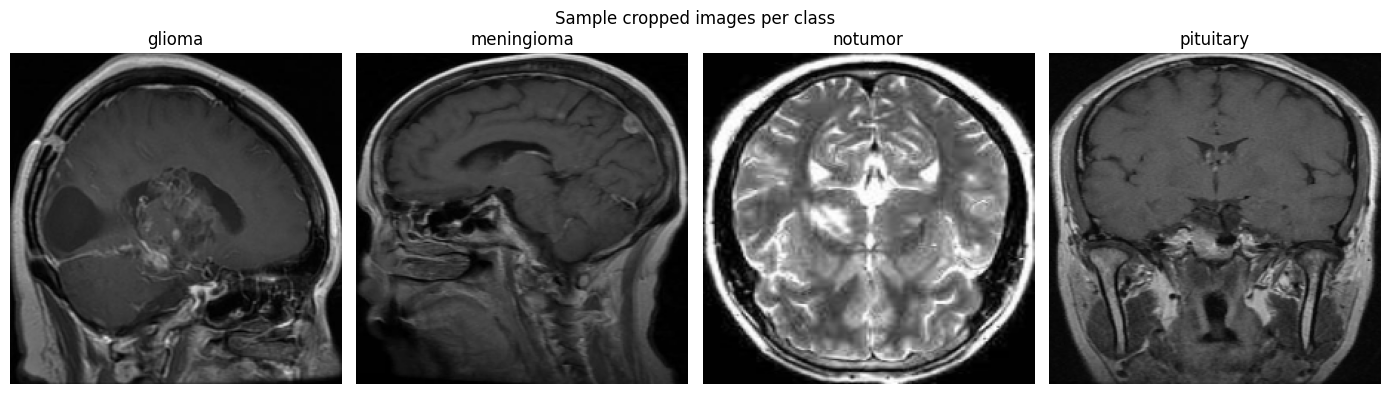

In [5]:
# Sanity check: visualize a few cropped samples
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, label in zip(axes, LABELS):
    idx = np.where(y_train == LABELS.index(label))[0][0]
    ax.imshow(X_train[idx])
    ax.set_title(label)
    ax.axis("off")
plt.suptitle("Sample cropped images per class")
plt.tight_layout()
plt.show()


## 4. Build tf.data Pipelines

Augmentation (flip / rotation / zoom / contrast) is implemented as Keras preprocessing layers
placed *inside* the model. Keras automatically applies them only during training (`training=True`)
and switches them off automatically at inference/evaluation — so validation and test data are
never augmented, which keeps evaluation numbers honest.

Class weights are computed from the training set to counter any class imbalance.


In [6]:
AUTOTUNE = tf.data.AUTOTUNE
BATCH_SIZE = 32

def make_dataset(X, y, shuffle=False, batch_size=BATCH_SIZE):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(X), seed=SEED)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(X_train, y_train, shuffle=True)
val_ds = make_dataset(X_val, y_val)
test_ds = make_dataset(X_test, y_test)

class_weights_arr = compute_class_weight(
    class_weight="balanced", classes=np.unique(y_train), y=y_train
)
class_weights = dict(enumerate(class_weights_arr))
print("Class weights:", {LABELS[k]: round(v, 3) for k, v in class_weights.items()})

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(height_factor=0.1, width_factor=0.1),  # brains aren't always centered
    layers.RandomContrast(0.1),
], name="data_augmentation")


Class weights: {'glioma': np.float64(1.0), 'meningioma': np.float64(1.0), 'notumor': np.float64(1.0), 'pituitary': np.float64(1.0)}


## 5. Baseline: Custom CNN Trained From Scratch

This is deliberately simple. Its job is to give you a real number to compare the transfer-learning
model against — "transfer learning gave us +X% over a from-scratch CNN" is a much stronger claim
than just reporting one model's accuracy in isolation.


In [7]:
def build_baseline_cnn(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=4):
    inputs = keras.Input(shape=input_shape)
    x = data_augmentation(inputs)
    x = layers.Rescaling(1.0 / 255)(x)

    for filters in [32, 64, 128, 256]:
        x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D()(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.4)(x)
    # With mixed_float16, the final layer must output float32 for numerical stability in the loss.
    outputs = layers.Dense(num_classes, activation="softmax", dtype="float32")(x)

    return keras.Model(inputs, outputs, name="baseline_cnn")


cnn_model = build_baseline_cnn()
cnn_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
cnn_model.summary()


Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 423,748 (1.62 MB)

 Trainable params: 422,788 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

In [8]:
cnn_callbacks = [
    callbacks.EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6),
    # Checkpoint on val_loss, not val_accuracy: with class imbalance, accuracy can look good
    # just from the model leaning on the majority class, while loss still reflects true confidence.
    callbacks.ModelCheckpoint("best_cnn.keras", monitor="val_loss", mode="min", save_best_only=True),
]

cnn_history = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=40,
    class_weight=class_weights,
    callbacks=cnn_callbacks,
)


Epoch 1/40
140/140 ━━━━━━━━━━━━━━━━━━━━ 36s 121ms/step - accuracy: 0.6344 - loss: 0.8998 - val_accuracy: 0.2580 - val_loss: 1.8058 - learning_rate: 0.0010
Epoch 2/40
140/140 ━━━━━━━━━━━━━━━━━━━━ 17s 118ms/step - accuracy: 0.7272 - loss: 0.6885 - val_accuracy: 0.4384 - val_loss: 1.9211 - learning_rate: 0.0010
Epoch 3/40
140/140 ━━━━━━━━━━━━━━━━━━━━ 17s 121ms/step - accuracy: 0.7623 - loss: 0.6069 - val_accuracy: 0.3973 - val_loss: 3.1839 - learning_rate: 0.0010
Epoch 4/40
140/140 ━━━━━━━━━━━━━━━━━━━━ 16s 117ms/step - accuracy: 0.7955 - loss: 0.5260 - val_accuracy: 0.6598 - val_loss: 0.9562 - learning_rate: 0.0010
Epoch 5/40
140/140 ━━━━━━━━━━━━━━━━━━━━ 20s 116ms/step - accuracy: 0.8141 - loss: 0.4871 - val_accuracy: 0.4482 - val_loss: 3.3896 - learning_rate: 0.0010
Epoch 6/40
140/140 ━━━━━━━━━━━━━━━━━━━━ 16s 117ms/step - accuracy: 0.8449 - loss: 0.4066 - val_accuracy: 0.4339 - val_loss: 2.7875 - learning_rate: 0.0010
Epoch 7/40
140/140 ━━━━━━━━━━━━━━━━━━━━ 16s 118ms/step - accuracy: 0.8

## 6. Transfer Learning: EfficientNetV2B0

Two-phase fine-tuning:
- **Phase 1:** freeze the pretrained backbone, train only the new classification head. This adapts
  the head to our 4 classes quickly without destroying the pretrained features.
- **Phase 2:** unfreeze the top portion of the backbone and fine-tune with a much lower learning
  rate, so the model can adapt its higher-level features to MRI scans specifically without
  catastrophically forgetting what it already learned from ImageNet.


In [9]:
def build_efficientnet(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=4):
    inputs = keras.Input(shape=input_shape)
    x = data_augmentation(inputs)
    x = efficientnet_preprocess(x)  # EfficientNetV2's own preprocessing (not simple /255)

    # EfficientNetV2B0: same drop-in usage as V1, but faster to train and more accurate.
    base_model = EfficientNetV2B0(include_top=False, weights="imagenet", input_tensor=x)
    base_model.trainable = False  # Phase 1: frozen backbone

    x = layers.GlobalAveragePooling2D()(base_model.output)
    x = layers.Dropout(0.3)(x)
    # With mixed_float16, the final layer must output float32 for numerical stability in the loss.
    outputs = layers.Dense(num_classes, activation="softmax", dtype="float32")(x)

    model = keras.Model(inputs, outputs, name="efficientnet_v2b0")
    return model, base_model


eff_model, eff_base = build_efficientnet()
eff_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
eff_model.summary()


24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "efficientnet_v2b0"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 224, 224,  │          0 │ input_layer_2[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ data_augmentatio… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          0 │ rescaling_1[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ normalization[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │      4,608 │ stem_activation[… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_bn  │ (None, 112, 112,  │         64 │ block1a_project_… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_ac… │ (None, 112, 112,  │          0 │ block1a_project_… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_conv │ (None, 56, 56,    │      9,216 │ block1a_project_… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_bn   │ (None, 56, 56,    │        256 │ block2a_expand_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_act… │ (None, 56, 56,    │          0 │ block2a_expand_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_project_co… │ (None, 56, 56,    │      2,048 │ block2a_expand_a… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_project_bn  │ (None, 56, 56,    │        128 │ block2a_project_… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_conv │ (None, 56, 56,    │     36,864 │ block2a_project_… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_bn   │ (None, 56, 56,    │        512 │ block2b_expand_c

 Total params: 5,924,436 (22.60 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 5,919,312 (22.58 MB)

In [10]:
# --- Phase 1: train the head only ---
phase1_callbacks = [
    callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
]

phase1_history = eff_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weights,
    callbacks=phase1_callbacks,
)


Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 34s 94ms/step - accuracy: 0.6830 - loss: 0.8025 - val_accuracy: 0.7955 - val_loss: 0.5735
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 9s 67ms/step - accuracy: 0.8031 - loss: 0.5404 - val_accuracy: 0.8232 - val_loss: 0.4860
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 9s 66ms/step - accuracy: 0.8283 - loss: 0.4694 - val_accuracy: 0.8116 - val_loss: 0.4812
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 71ms/step - accuracy: 0.8395 - loss: 0.4478 - val_accuracy: 0.8107 - val_loss: 0.4940
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 9s 64ms/step - accuracy: 0.8498 - loss: 0.4161 - val_accuracy: 0.8170 - val_loss: 0.4677
Epoch 6/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 9s 67ms/step - accuracy: 0.8504 - loss: 0.3952 - val_accuracy: 0.8223 - val_loss: 0.4574
Epoch 7/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 67ms/step - accuracy: 0.8574 - loss: 0.3830 - val_accuracy: 0.8268 - val_loss: 0.4360
Epoch 8/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 9s 67ms/step - accuracy: 0.8614 - loss: 0.3764 - val_a

In [11]:
# --- Phase 2: unfreeze top layers and fine-tune with a low learning rate ---
eff_base.trainable = True
FINE_TUNE_AT = len(eff_base.layers) - 30  # unfreeze roughly the last 30 layers

for layer in eff_base.layers[:FINE_TUNE_AT]:
    layer.trainable = False

# Keep every BatchNormalization layer frozen, even among the "unfrozen" top layers.
# If BN is left trainable during fine-tuning, its running mean/variance get updated using
# our small fine-tuning batches, which is very easy to destabilize — especially at low batch
# sizes and low learning rates. The pretrained BN statistics (learned on millions of ImageNet
# images) are almost always better than what a few thousand MRI images can re-estimate.
# This keeps BN layers in inference mode throughout fine-tuning while their neighboring
# Conv/Dense layers still learn.
bn_frozen_count = 0
for layer in eff_base.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False
        bn_frozen_count += 1

print(f"Froze {bn_frozen_count} BatchNormalization layers (kept in inference mode during fine-tuning).")

eff_model.compile(
    optimizer=keras.optimizers.Adam(1e-5),  # much lower LR for fine-tuning
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

phase2_callbacks = [
    callbacks.EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-7),
    callbacks.ModelCheckpoint("best_efficientnet.keras", monitor="val_loss", mode="min", save_best_only=True),
]

phase2_history = eff_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    class_weight=class_weights,
    callbacks=phase2_callbacks,
)


Froze 59 BatchNormalization layers (kept in inference mode during fine-tuning).
Epoch 1/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 34s 107ms/step - accuracy: 0.8663 - loss: 0.3558 - val_accuracy: 0.8518 - val_loss: 0.3834 - learning_rate: 1.0000e-05
Epoch 2/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 11s 79ms/step - accuracy: 0.8732 - loss: 0.3415 - val_accuracy: 0.8571 - val_loss: 0.3690 - learning_rate: 1.0000e-05
Epoch 3/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 20s 73ms/step - accuracy: 0.8692 - loss: 0.3393 - val_accuracy: 0.8446 - val_loss: 0.3867 - learning_rate: 1.0000e-05
Epoch 4/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 73ms/step - accuracy: 0.8737 - loss: 0.3386 - val_accuracy: 0.8473 - val_loss: 0.3914 - learning_rate: 1.0000e-05
Epoch 5/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 71ms/step - accuracy: 0.8772 - loss: 0.3302 - val_accuracy: 0.8482 - val_loss: 0.3885 - learning_rate: 1.0000e-05
Epoch 6/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 71ms/step - accuracy: 0.8821 - loss: 0.3140 - val_accuracy: 0.8518 - val_loss: 0.3746

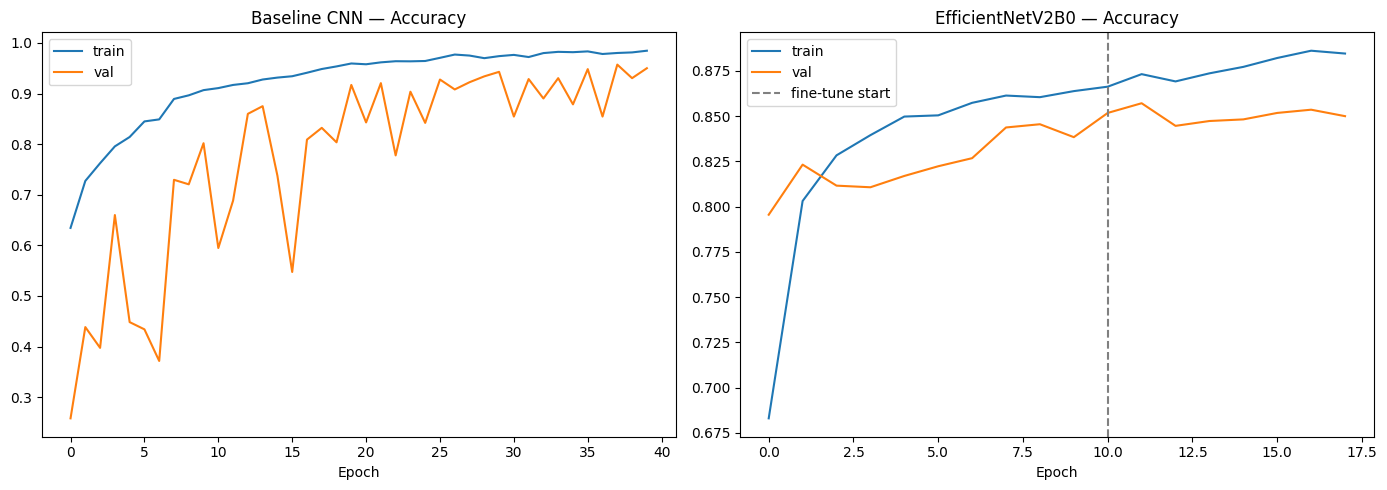

In [12]:
# Training curves for both models
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(cnn_history.history["accuracy"], label="train")
axes[0].plot(cnn_history.history["val_accuracy"], label="val")
axes[0].set_title("Baseline CNN — Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].legend()

eff_acc = phase1_history.history["accuracy"] + phase2_history.history["accuracy"]
eff_val_acc = phase1_history.history["val_accuracy"] + phase2_history.history["val_accuracy"]
axes[1].plot(eff_acc, label="train")
axes[1].plot(eff_val_acc, label="val")
axes[1].axvline(len(phase1_history.history["accuracy"]), color="gray", linestyle="--", label="fine-tune start")
axes[1].set_title("EfficientNetV2B0 — Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()


## 7. Final Evaluation — On the Held-Out Test Set Only

This is the first and only time either model sees `X_test` / `y_test`. Both models are scored the
same way so the comparison between "from scratch" and "transfer learning" is fair.


50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step

=== Baseline CNN ===
Test Accuracy:     0.9156
Macro F1:          0.9132
Weighted F1:       0.9132

              precision    recall  f1-score   support

      glioma       0.97      0.76      0.85       400
  meningioma       0.90      0.92      0.91       400
     notumor       0.88      1.00      0.93       400
   pituitary       0.93      0.99      0.96       400

    accuracy                           0.92      1600
   macro avg       0.92      0.92      0.91      1600
weighted avg       0.92      0.92      0.91      1600



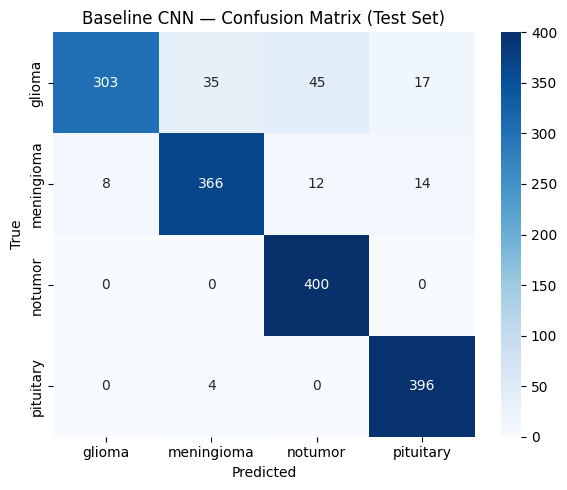

50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step

=== EfficientNetV2B0 (fine-tuned) ===
Test Accuracy:     0.8275
Macro F1:          0.8213
Weighted F1:       0.8213

              precision    recall  f1-score   support

      glioma       0.85      0.70      0.77       400
  meningioma       0.75      0.65      0.69       400
     notumor       0.91      0.99      0.94       400
   pituitary       0.80      0.97      0.88       400

    accuracy                           0.83      1600
   macro avg       0.83      0.83      0.82      1600
weighted avg       0.83      0.83      0.82      1600



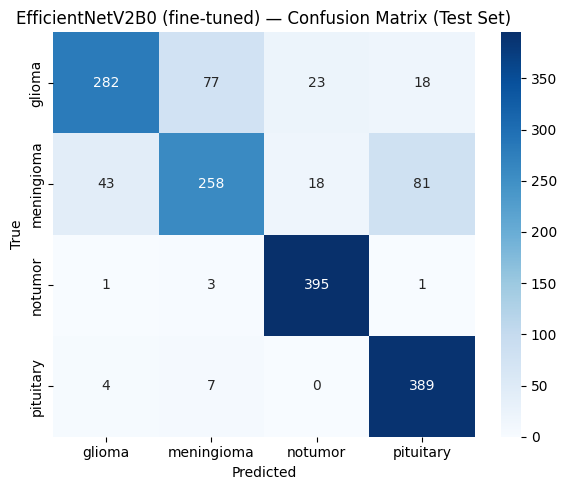


--- Summary ---
                  accuracy  f1_macro  f1_weighted
Model                                            
Baseline CNN        0.9156    0.9132       0.9132
EfficientNetV2B0    0.8275    0.8213       0.8213

Accuracy improvement from transfer learning: -8.81 points
Macro F1 improvement from transfer learning:  -9.19 points


In [13]:
def evaluate_model(model, dataset, y_true, name):
    y_pred_probs = model.predict(dataset)
    y_pred = np.argmax(y_pred_probs, axis=1)

    acc = accuracy_score(y_true, y_pred)
    # Macro F1 weighs every class equally regardless of how many samples it has — this is the
    # number to trust over accuracy on a medical dataset, since accuracy alone can look fine
    # even if the model is quietly weak on a minority class (e.g. missing more meningiomas).
    f1_macro = f1_score(y_true, y_pred, average="macro")
    f1_weighted = f1_score(y_true, y_pred, average="weighted")

    print(f"\n=== {name} ===")
    print(f"Test Accuracy:     {acc:.4f}")
    print(f"Macro F1:          {f1_macro:.4f}")
    print(f"Weighted F1:       {f1_weighted:.4f}")
    print()
    print(classification_report(y_true, y_pred, target_names=LABELS))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=LABELS, yticklabels=LABELS)
    plt.title(f"{name} — Confusion Matrix (Test Set)")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

    return {"accuracy": acc, "f1_macro": f1_macro, "f1_weighted": f1_weighted}, y_pred


cnn_metrics, cnn_test_pred = evaluate_model(cnn_model, test_ds, y_test, "Baseline CNN")
eff_metrics, eff_test_pred = evaluate_model(eff_model, test_ds, y_test, "EfficientNetV2B0 (fine-tuned)")

print("\n--- Summary ---")
summary_df = pd.DataFrame([
    {"Model": "Baseline CNN", **cnn_metrics},
    {"Model": "EfficientNetV2B0", **eff_metrics},
]).set_index("Model")
print(summary_df.round(4))

print(f"\nAccuracy improvement from transfer learning: "
      f"{(eff_metrics['accuracy'] - cnn_metrics['accuracy']) * 100:+.2f} points")
print(f"Macro F1 improvement from transfer learning:  "
      f"{(eff_metrics['f1_macro'] - cnn_metrics['f1_macro']) * 100:+.2f} points")


## 8. Grad-CAM — Explaining the EfficientNetV2B0 Predictions

Grad-CAM shows which regions of the MRI most influenced the model's prediction, by looking at the
gradient of the predicted class with respect to the last convolutional layer's feature maps. This
turns the model from a black box into something you can actually defend in an interview: "here's
*where* it's looking, and it lines up with the tumor region."


In [15]:
# ============================================================
# Grad-CAM for the Custom CNN
# ============================================================

def find_last_conv_layer(model):
    """
    Automatically find the last Conv2D layer in the model.
    """
    for layer in reversed(model.layers):
        if isinstance(layer, layers.Conv2D):
            return layer.name

    raise ValueError("No Conv2D layer found in the model.")


LAST_CONV_LAYER = find_last_conv_layer(cnn_model)

print("Last convolutional layer:", LAST_CONV_LAYER)

Last convolutional layer: conv2d_3


In [16]:
def get_gradcam_heatmap(model, img_array, last_conv_layer_name, pred_index=None):

    # Model that returns:
    # 1. Last convolutional feature maps
    # 2. Final model prediction
    grad_model = keras.Model(
        inputs=model.inputs,
        outputs=[
            model.get_layer(last_conv_layer_name).output,
            model.output
        ]
    )

    img_tensor = tf.convert_to_tensor(
        img_array,
        dtype=tf.float32
    )

    with tf.GradientTape() as tape:

        conv_outputs, predictions = grad_model(
            img_tensor,
            training=False
        )

        if pred_index is None:
            pred_index = tf.argmax(predictions[0])

        class_score = predictions[:, pred_index]

    # Gradient of predicted class score
    # with respect to convolutional features
    grads = tape.gradient(
        class_score,
        conv_outputs
    )

    # Importance of each feature map
    pooled_grads = tf.reduce_mean(
        grads,
        axis=(0, 1, 2)
    )

    # Remove batch dimension
    conv_outputs = conv_outputs[0]

    # Weighted combination of feature maps
    heatmap = tf.reduce_sum(
        conv_outputs * pooled_grads,
        axis=-1
    )

    # Keep positive influences
    heatmap = tf.maximum(heatmap, 0)

    # Normalize to [0, 1]
    max_value = tf.reduce_max(heatmap)

    if max_value > 0:
        heatmap = heatmap / max_value

    return (
        heatmap.numpy().astype(np.float32),
        int(pred_index)
    )

In [17]:
def overlay_gradcam(img_rgb_uint8, heatmap, alpha=0.4):

    heatmap = np.asarray(
        heatmap,
        dtype=np.float32
    )

    heatmap = np.squeeze(heatmap)

    if heatmap.ndim != 2:
        raise ValueError(
            f"Expected 2D heatmap, got shape {heatmap.shape}"
        )

    # Resize heatmap to MRI dimensions
    heatmap_resized = cv2.resize(
        heatmap,
        (
            img_rgb_uint8.shape[1],
            img_rgb_uint8.shape[0]
        ),
        interpolation=cv2.INTER_LINEAR
    )

    heatmap_resized = np.clip(
        heatmap_resized,
        0,
        1
    )

    # Convert to 0-255
    heatmap_uint8 = np.uint8(
        255 * heatmap_resized
    )

    # Apply color map
    heatmap_color = cv2.applyColorMap(
        heatmap_uint8,
        cv2.COLORMAP_JET
    )

    # OpenCV BGR → RGB
    heatmap_color = cv2.cvtColor(
        heatmap_color,
        cv2.COLOR_BGR2RGB
    )

    # Overlay heatmap on original MRI
    overlay = cv2.addWeighted(
        img_rgb_uint8,
        1 - alpha,
        heatmap_color,
        alpha,
        0
    )

    return overlay

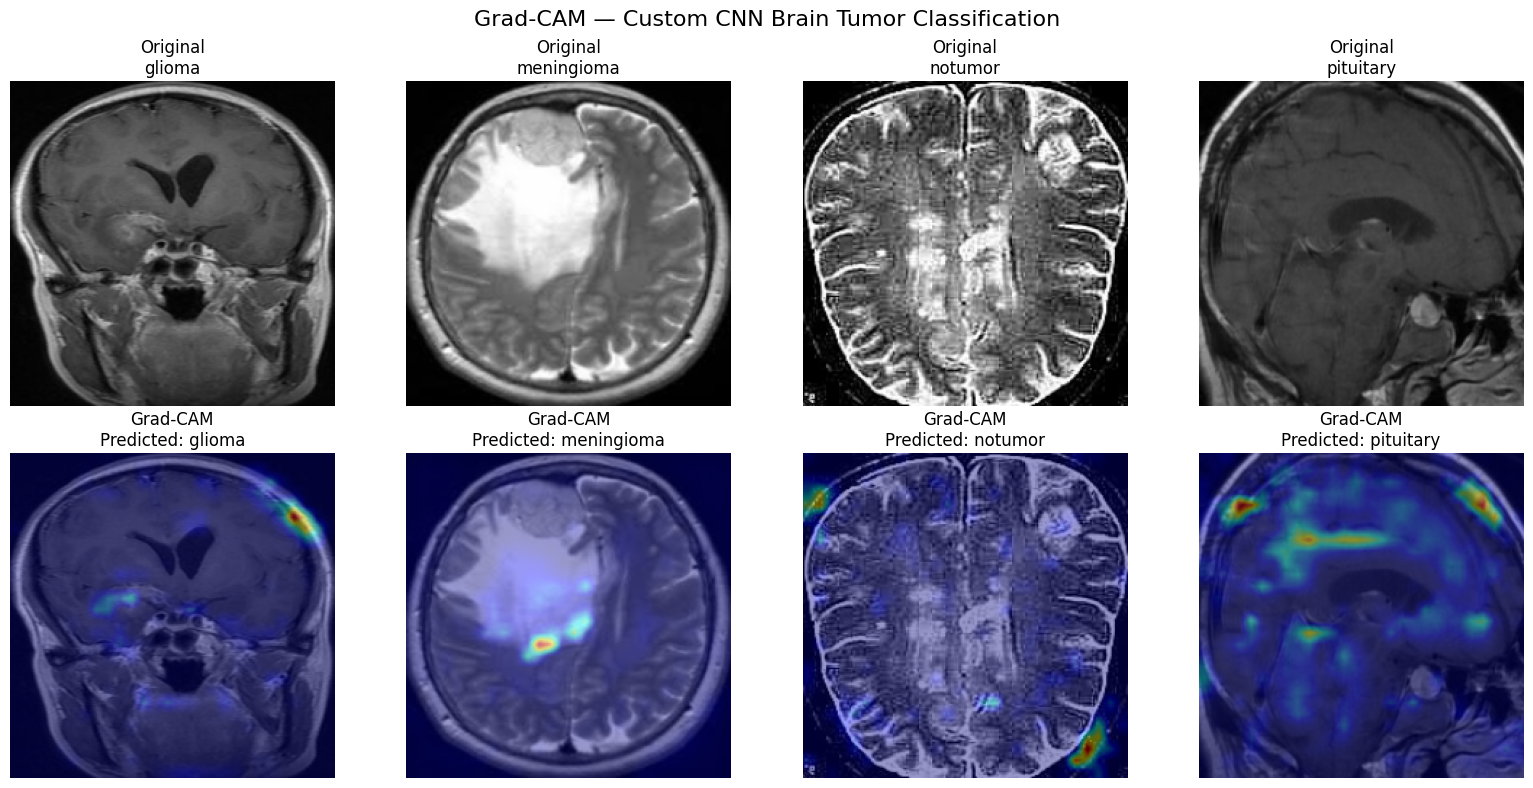

In [18]:
fig, axes = plt.subplots(
    2,
    4,
    figsize=(16, 8)
)

for col, label in enumerate(LABELS):

    class_idx = LABELS.index(label)

    # Find images where:
    # actual class == predicted class
    matches = np.where(
        (y_test == class_idx) &
        (cnn_test_pred == class_idx)
    )[0]

    if len(matches) == 0:
        print(f"No correctly classified image for {label}")
        continue

    # Take first correctly classified example
    idx = matches[0]

    img = X_test[idx]

    img_batch = np.expand_dims(
        img,
        axis=0
    ).astype(np.float32)

    # Generate Grad-CAM
    heatmap, pred_idx = get_gradcam_heatmap(
        cnn_model,
        img_batch,
        LAST_CONV_LAYER
    )

    overlay = overlay_gradcam(
        img,
        heatmap,
        alpha=0.4
    )

    # -----------------------
    # Original MRI
    # -----------------------

    axes[0, col].imshow(img)

    axes[0, col].set_title(
        f"Original\n{label}"
    )

    axes[0, col].axis("off")

    # -----------------------
    # Grad-CAM
    # -----------------------

    axes[1, col].imshow(overlay)

    axes[1, col].set_title(
        f"Grad-CAM\nPredicted: {LABELS[pred_idx]}"
    )

    axes[1, col].axis("off")


plt.suptitle(
    "Grad-CAM — Custom CNN Brain Tumor Classification",
    fontsize=16
)

plt.tight_layout()
plt.show()

## 9. Save Both Models

Save in the native Keras format. These files are what you'll load in your FastAPI backend.


In [19]:
cnn_model.save("baseline_cnn_final.keras")
eff_model.save("efficientnet_v2b0_final.keras")
print("Saved: baseline_cnn_final.keras, efficientnet_v2b0_final.keras")


Saved: baseline_cnn_final.keras, efficientnet_v2b0_final.keras


## 10. Summary & Next Steps

**What this pipeline demonstrates:**
- Clean preprocessing (contour cropping) instead of feeding raw noisy scans to the model.
- Methodologically honest evaluation — a true held-out test set, untouched until the final step.
- A fair, like-for-like comparison between a from-scratch CNN and a transfer-learning model, with
  a quantified improvement number you can cite directly.
- Explainability via Grad-CAM, so the model's decisions aren't a black box.


